In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded!")

All libraries loaded!


In [2]:
from google.colab import files
uploaded = files.upload()

Saving 0f484464-3cc8-4bfc-968b-b1a9fc4d4b1d.csv to 0f484464-3cc8-4bfc-968b-b1a9fc4d4b1d.csv


In [3]:
import os
print(os.listdir('/content'))

['.config', '0f484464-3cc8-4bfc-968b-b1a9fc4d4b1d.csv', 'sample_data']


In [4]:
df = pd.read_csv('/content/0f484464-3cc8-4bfc-968b-b1a9fc4d4b1d.csv')
print(df.shape)
print(df.head())
print(df.dtypes)
print(df.isnull().sum())
print(df['target_5yrs'].value_counts())

(1340, 22)
   Unnamed: 0             name  gp   min  pts  fgm  fga    fg  3p_made  3pa  \
0           0   Brandon Ingram  36  27.4  7.4  2.6  7.6  34.7      0.5  2.1   
1           1  Andrew Harrison  35  26.9  7.2  2.0  6.7  29.6      0.7  2.8   
2           2   JaKarr Sampson  74  15.3  5.2  2.0  4.7  42.2      0.4  1.7   
3           3      Malik Sealy  58  11.6  5.7  2.3  5.5  42.6      0.1  0.5   
4           4      Matt Geiger  48  11.5  4.5  1.6  3.0  52.4      0.0  0.1   

   ...  fta    ft  oreb  dreb  reb  ast  stl  blk  tov  target_5yrs  
0  ...  2.3  69.9   0.7   3.4  4.1  1.9  0.4  0.4  1.3            0  
1  ...  3.4  76.5   0.5   2.0  2.4  3.7  1.1  0.5  1.6            0  
2  ...  1.3  67.0   0.5   1.7  2.2  1.0  0.5  0.3  1.0            0  
3  ...  1.3  68.9   1.0   0.9  1.9  0.8  0.6  0.1  1.0            1  
4  ...  1.9  67.4   1.0   1.5  2.5  0.3  0.3  0.4  0.8            1  

[5 rows x 22 columns]
Unnamed: 0       int64
name            object
gp               int64
mi

In [5]:
# Define target variable
y = df['target_5yrs']
print("Target variable:")
print(y.value_counts())
print()

# Drop non-predictive columns
df = df.drop(['Unnamed: 0', 'name'], axis=1)
print("Shape after dropping columns:", df.shape)
print("Remaining columns:", df.columns.tolist())

Target variable:
target_5yrs
1    831
0    509
Name: count, dtype: int64

Shape after dropping columns: (1340, 20)
Remaining columns: ['gp', 'min', 'pts', 'fgm', 'fga', 'fg', '3p_made', '3pa', '3p', 'ftm', 'fta', 'ft', 'oreb', 'dreb', 'reb', 'ast', 'stl', 'blk', 'tov', 'target_5yrs']


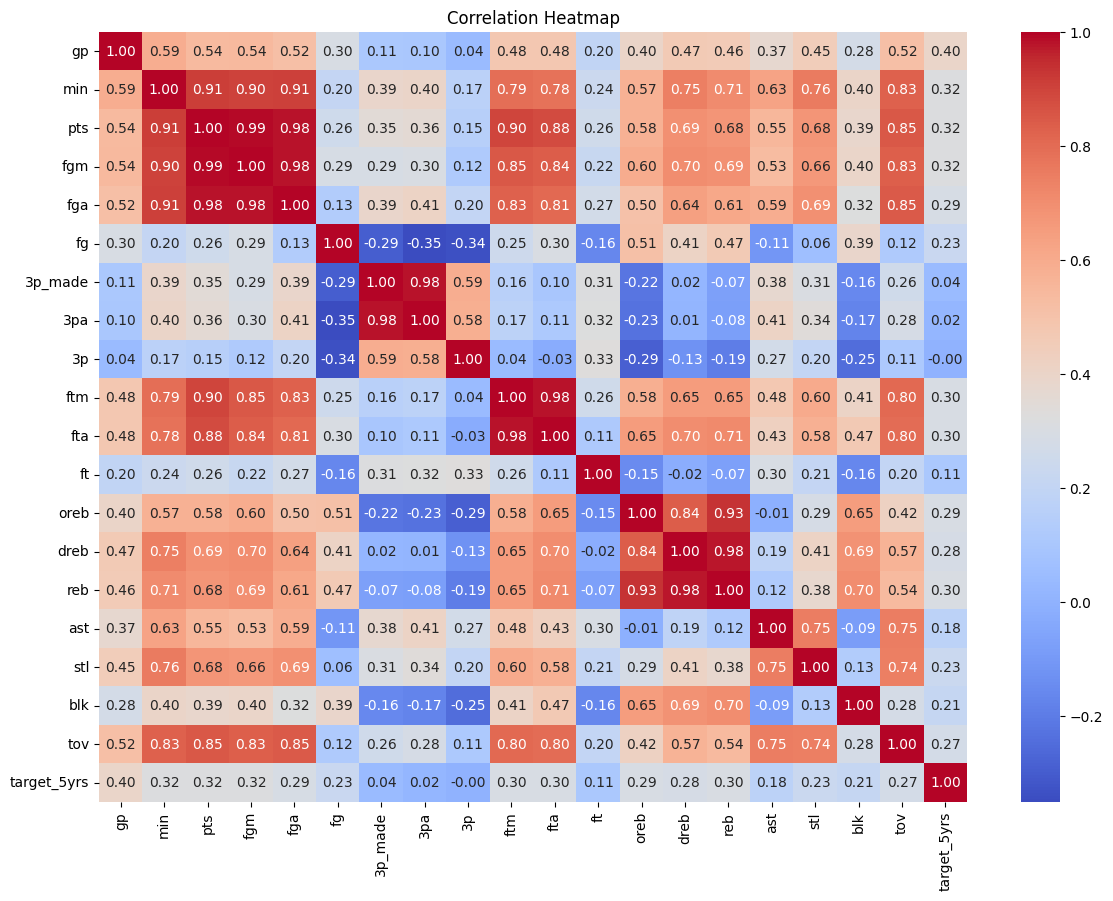

Correlation with target_5yrs:
target_5yrs    1.000000
gp             0.396833
min            0.317805
fgm            0.317594
pts            0.315981
reb            0.299406
ftm            0.296841
fta            0.296089
oreb           0.293307
fga            0.292660
dreb           0.284677
tov            0.272348
stl            0.229811
fg             0.227134
blk            0.210114
ast            0.175353
ft             0.106706
3p_made        0.036619
3pa            0.018110
3p            -0.000004
Name: target_5yrs, dtype: float64


In [6]:
# Correlation matrix
corr = df.corr()

# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Show features highly correlated with target
print("Correlation with target_5yrs:")
print(corr['target_5yrs'].sort_values(ascending=False))

In [7]:
# Drop highly correlated redundant features
cols_to_drop = ['fgm', 'fga', 'oreb', 'dreb', 'fta', '3pa']
df = df.drop(cols_to_drop, axis=1)

print("Shape after dropping redundant features:", df.shape)
print("Remaining columns:", df.columns.tolist())

Shape after dropping redundant features: (1340, 14)
Remaining columns: ['gp', 'min', 'pts', 'fg', '3p_made', '3p', 'ftm', 'ft', 'reb', 'ast', 'stl', 'blk', 'tov', 'target_5yrs']


In [8]:
# Engineer new composite features
df['pts_per_min'] = df['pts'] / (df['min'] + 0.001)
df['efficiency'] = (df['pts'] + df['reb'] + df['ast'] + df['stl'] + df['blk']) - df['tov']

print("New features added!")
print(df[['pts', 'min', 'pts_per_min', 'efficiency']].head())
print()
print("Shape after feature engineering:", df.shape)

New features added!
   pts   min  pts_per_min  efficiency
0  7.4  27.4     0.270063        12.9
1  7.2  26.9     0.267648        13.3
2  5.2  15.3     0.339847         8.2
3  5.7  11.6     0.491337         8.1
4  4.5  11.5     0.391270         7.2

Shape after feature engineering: (1340, 16)


In [9]:
# Check for missing values after feature engineering
print("Missing values after feature engineering:")
print(df.isnull().sum())
print()
print("Total missing values:", df.isnull().sum().sum())
print()

# Drop any rows with missing values if they exist
df = df.dropna()
print("Final shape:", df.shape)

Missing values after feature engineering:
gp             0
min            0
pts            0
fg             0
3p_made        0
3p             0
ftm            0
ft             0
reb            0
ast            0
stl            0
blk            0
tov            0
target_5yrs    0
pts_per_min    0
efficiency     0
dtype: int64

Total missing values: 0

Final shape: (1340, 16)


In [10]:
# Final dataset summary
print("=" * 55)
print("NBA FEATURE ENGINEERING - FINAL SUMMARY")
print("=" * 55)
print()
print("ORIGINAL DATASET: 1340 rows, 22 columns")
print("FINAL DATASET:    1340 rows, 16 columns")
print()
print("COLUMNS DROPPED:")
print("- Unnamed: 0  — index column, adds no value")
print("- name        — player name, causes data leakage")
print("- fgm, fga    — redundant with pts (corr=0.99)")
print("- oreb, dreb  — redundant with reb (corr=0.98)")
print("- fta         — redundant with ftm (corr=0.98)")
print("- 3pa         — redundant with 3p_made (corr=0.98)")
print()
print("NEW FEATURES CREATED:")
print("- pts_per_min — scoring efficiency per minute")
print("- efficiency  — overall player impact score")
print()
print("MISSING VALUES: 0")
print("TARGET VARIABLE: target_5yrs (1=lasted 5yrs, 0=didnt)")
print()
print("FINAL COLUMNS:")
print(df.columns.tolist())
print("=" * 55)

NBA FEATURE ENGINEERING - FINAL SUMMARY

ORIGINAL DATASET: 1340 rows, 22 columns
FINAL DATASET:    1340 rows, 16 columns

COLUMNS DROPPED:
- Unnamed: 0  — index column, adds no value
- name        — player name, causes data leakage
- fgm, fga    — redundant with pts (corr=0.99)
- oreb, dreb  — redundant with reb (corr=0.98)
- fta         — redundant with ftm (corr=0.98)
- 3pa         — redundant with 3p_made (corr=0.98)

NEW FEATURES CREATED:
- pts_per_min — scoring efficiency per minute
- efficiency  — overall player impact score

MISSING VALUES: 0
TARGET VARIABLE: target_5yrs (1=lasted 5yrs, 0=didnt)

FINAL COLUMNS:
['gp', 'min', 'pts', 'fg', '3p_made', '3p', 'ftm', 'ft', 'reb', 'ast', 'stl', 'blk', 'tov', 'target_5yrs', 'pts_per_min', 'efficiency']
